<a href="https://colab.research.google.com/github/amida96/ciencia-de-datos-semana-8/blob/main/ciencia_de_datos_sem_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
import numpy as np

def pipeline_carga_y_limpieza(ruta_archivo):
    """Carga los datos reales, maneja tipos de variables y limpia valores nulos."""
    try:
        # Carga del dataset operativo
        # Check file extension to use appropriate reader
        if ruta_archivo.endswith('.csv'):
            df = pd.read_csv(ruta_archivo)
        elif ruta_archivo.endswith(('.xlsx', '.xls')):
            df = pd.read_excel(ruta_archivo)
        else:
            print(f"Error: Formato de archivo no soportado para la ruta: {ruta_archivo}")
            return None

        # Print columns to debug KeyError
        print("DataFrame columns after loading:", df.columns)

        # Conversión del campo temporal al tipo datetime, especificando el formato
        df['fecha_registro'] = pd.to_datetime(df['fecha_registro'], format='mixed')

        # Limpieza: Eliminar registros donde la variable crítica de salida sea nula
        df = df.dropna(subset=['DBO_salida_mg_L'])

        # Ingeniería de características: Cálculo de la eficiencia de remoción (%)
        df['eficiencia_remocion_DBO'] = ((df['DBO_entrada_mg_L'] - df['DBO_salida_mg_L']) / df['DBO_entrada_mg_L']) * 100

        return df
    except FileNotFoundError:
        print(f"Error Crítico: No se encontró el archivo en la ruta: {ruta_archivo}")
        return None

In [11]:
import os

def generar_reportes_valor(df_operativo):
    """Genera reportes de valor a partir del DataFrame operativo y los exporta a Excel."""

    # Definir la ruta base para guardar los archivos en Google Drive
    # Ajusta esta ruta según donde quieras guardar tus archivos en Drive
    ruta_base_salida = '/content/drive/MyDrive/'

    # 1. Reporte de Alertas Operativas Críticas
    # Filtrar datos donde el cumplimiento de norma es 0
    alertas_criticas = df_operativo[df_operativo['cumplimiento_norma'] == 0]
    ruta_alertas = os.path.join(ruta_base_salida, 'alertas_operativas_criticas.xlsx')
    alertas_criticas.to_excel(ruta_alertas, index=False)
    print(f"Reporte de Alertas Operativas Críticas exportado a: {ruta_alertas}")

    # 2. Reporte Gerencial Resumen
    # Agrupar por planta y calcular promedios de métricas clave
    reporte_gerencial = df_operativo.groupby('planta').agg(
        promedio_DBO_entrada=('DBO_entrada_mg_L', 'mean'),
        promedio_DBO_salida=('DBO_salida_mg_L', 'mean'),
        promedio_eficiencia_remocion=('eficiencia_remocion_DBO', 'mean'),
        total_caudal_m3_d=('caudal_entrada_m3_d', 'sum')
    ).reset_index()

    ruta_gerencial = os.path.join(ruta_base_salida, 'reporte_gerencial_resumen.xlsx')
    reporte_gerencial.to_excel(ruta_gerencial, index=False)
    print(f"Reporte Gerencial Resumen exportado a: {ruta_gerencial}")

    print("Todos los reportes han sido generados y guardados.")

In [12]:
# Definición de la fuente de datos (Nombre exacto del archivo analizado)
FUENTE_DATOS = '/content/drive/MyDrive/ ciencia de datos semana 8 /dataset_set_A_aguas_residuales.xlsx'
# Ejecución del pipeline continuo
data_operativa = pipeline_carga_y_limpieza(FUENTE_DATOS)

if data_operativa is not None:
    generar_reportes_valor(data_operativa)
    print("Flujo finalizado con éxito: Salidas diferenciadas exportadas en Excel.")

DataFrame columns after loading: Index(['fecha_registro', 'planta', 'caudal_entrada_m3_d', 'DBO_entrada_mg_L',
       'SST_entrada_mg_L', 'pH_entrada', 'energia_aeracion_kWh',
       'lodos_generados_kg_d', 'DBO_salida_mg_L', 'cumplimiento_norma'],
      dtype='object')
Reporte de Alertas Operativas Críticas exportado a: /content/drive/MyDrive/alertas_operativas_criticas.xlsx
Reporte Gerencial Resumen exportado a: /content/drive/MyDrive/reporte_gerencial_resumen.xlsx
Todos los reportes han sido generados y guardados.
Flujo finalizado con éxito: Salidas diferenciadas exportadas en Excel.


In [9]:
print('Resumen estadístico de data_operativa:')
display(data_operativa.describe())

Resumen estadístico de data_operativa:


,fecha_registro,caudal_entrada_m3_d,DBO_entrada_mg_L,SST_entrada_mg_L,pH_entrada,energia_aeracion_kWh,lodos_generados_kg_d,DBO_salida_mg_L,cumplimiento_norma,eficiencia_remocion_DBO
count,200,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.00000,200.000000
mean,2025-08-29 15:50:24,5059.285000,280.145000,232.670000,7.16240,1256.394500,428.795500,36.177500,0.22500,87.092908
min,2025-07-01 00:00:00,1500.000000,90.000000,70.000000,6.18000,279.700000,113.700000,10.200000,0.00000,80.692308
25%,2025-07-31 00:00:00,4193.750000,223.000000,192.500000,6.84750,950.650000,321.175000,26.075000,0.00000,84.754466
50%,2025-08-30 12:00:00,5092.500000,284.000000,233.500000,7.14000,1212.850000,429.700000,35.150000,0.00000,86.999935
75%,2025-09-29 06:00:00,6037.750000,333.250000,277.500000,7.45250,1516.750000,524.825000,45.825000,0.00000,89.679486
max,2025-10-28 00:00:00,9205.000000,481.000000,391.000000,8.27000,2434.000000,971.700000,79.000000,1.00000,93.431953
std,NaN,1410.971334,75.566497,64.289398,0.42381,420.146335,144.744253,13.259427,0.41863,3.099086


In [13]:
!ls "/content/drive/MyDrive/Semana 8/"

ls: cannot access '/content/drive/MyDrive/Semana 8/': No such file or directory


In [ ]:
!ls -F

alertas_operativas_criticas.xlsx  reporte_gerencial_resumen.xlsx
drive/				  sample_data/


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls -F '/content/drive/MyDrive/'

 0000768002-19476364.pdf
'ahora que ya sabemos que corregir necesito que me....gsheet'
'CERTIFICADO OS10 CRISTOBAL MERINO GUTIERREZ.pdf'
'Ciencia de datos'/
' ciencia de datos semana 8 '/
'Colab Notebooks'/
 corriculum.docx
'Creación de Diagramas de Base de Datos.gsheet'
'Curriculum Vitae os10.gdoc'
'Curriculum Vitae os10.pdf'
'Google AI Studio'/
'Guía de Apoyo_para_Desarrollo_de_Informe_Tecnico_de_Práctica_Profesional.gdoc'
'Guía de Apoyo_para_Desarrollo_de_Informe_Tecnico_de_Práctica_Profesional.pdf'
 jdjdjd.gmap
'Plantilla para desarrollar proyecto de mejora.docx'
'proyecto informatico.gdoc'
 Untitled0.ipynb


In [15]:
data_operativa.corr(numeric_only=True)

,caudal_entrada_m3_d,DBO_entrada_mg_L,SST_entrada_mg_L,pH_entrada,energia_aeracion_kWh,lodos_generados_kg_d,DBO_salida_mg_L,cumplimiento_norma,eficiencia_remocion_DBO
caudal_entrada_m3_d,1.000000,0.060814,0.107663,-0.063053,0.853222,0.876796,0.103671,-0.176349,-0.122776
DBO_entrada_mg_L,0.060814,1.000000,0.011200,-0.108769,0.105483,0.065883,0.758851,-0.433426,-0.008123
SST_entrada_mg_L,0.107663,0.011200,1.000000,-0.142669,0.100990,0.060725,0.065765,-0.309600,-0.108030
pH_entrada,-0.063053,-0.108769,-0.142669,1.000000,-0.054433,-0.030735,-0.135405,0.032629,0.059700
energia_aeracion_kWh,0.853222,0.105483,0.100990,-0.054433,1.000000,0.776162,0.144478,-0.172641,-0.113670
lodos_generados_kg_d,0.876796,0.065883,0.060725,-0.030735,0.776162,1.000000,0.137530,-0.198718,-0.163875
DBO_salida_mg_L,0.103671,0.758851,0.065765,-0.135405,0.144478,0.137530,1.000000,-0.587074,-0.632266
cumplimiento_norma,-0.176349,-0.433426,-0.309600,0.032629,-0.172641,-0.198718,-0.587074,1.000000,0.460356
eficiencia_remocion_DBO,-0.122776,-0.008123,-0.108030,0.059700,-0.113670,-0.163875,-0.632266,0.460356,1.000000


In [17]:
data_operativa['eficiencia'] = (data_operativa['DBO_entrada_mg_L'] - data_operativa['DBO_salida_mg_L']) / data_operativa['DBO_entrada_mg_L'] * 100

In [18]:
data_operativa.head()

,fecha_registro,planta,caudal_entrada_m3_d,DBO_entrada_mg_L,SST_entrada_mg_L,pH_entrada,energia_aeracion_kWh,lodos_generados_kg_d,DBO_salida_mg_L,cumplimiento_norma,eficiencia_remocion_DBO,eficiencia
0,2025-08-17,Planta Sur,6562,271,324,7.12,1261.1,440.3,40.0,0,85.239852,85.239852
1,2025-09-07,Planta Sur,5336,322,230,7.01,1629.3,561.2,26.8,1,91.677019,91.677019
2,2025-07-26,Planta Norte,5755,318,282,6.79,1469.2,441.6,45.2,0,85.786164,85.786164
3,2025-10-27,Planta Centro,6840,216,167,7.01,1764.8,560.0,38.0,0,82.407407,82.407407
4,2025-09-06,Planta Centro,6803,326,200,7.55,1409.3,654.0,32.1,0,90.153374,90.153374


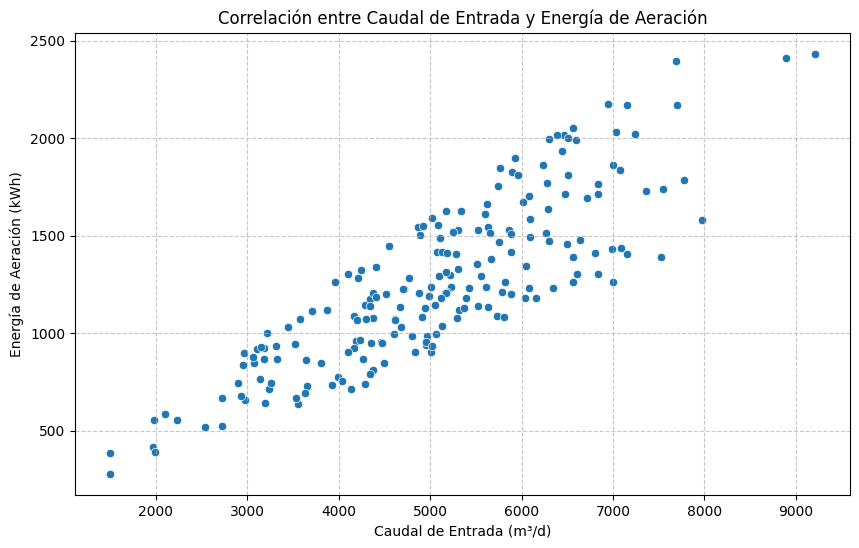

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='caudal_entrada_m3_d', y='energia_aeracion_kWh', data=data_operativa)
plt.title('Correlación entre Caudal de Entrada y Energía de Aeración')
plt.xlabel('Caudal de Entrada (m³/d)')
plt.ylabel('Energía de Aeración (kWh)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [25]:
from scipy import stats

In [37]:
z_scores = stats.zscore(data_operativa['caudal_entrada_m3_d'])

In [43]:
anomalias = data_operativa[abs(z_scores) > 2]
anomalias

,fecha_registro,planta,caudal_entrada_m3_d,DBO_entrada_mg_L,SST_entrada_mg_L,pH_entrada,energia_aeracion_kWh,lodos_generados_kg_d,DBO_salida_mg_L,cumplimiento_norma,eficiencia_remocion_DBO,eficiencia
46,2025-10-19,Planta Centro,1973,314,243,7.25,415.6,183.0,35.4,0,88.726115,88.726115
49,2025-10-08,Planta Centro,2229,352,168,7.64,553.1,172.1,51.0,0,85.511364,85.511364
84,2025-07-20,Planta Norte,9205,196,207,6.54,2434.0,971.7,36.5,0,81.377551,81.377551
118,2025-08-18,Planta Sur,8894,344,389,7.91,2410.0,938.3,46.5,0,86.482558,86.482558
119,2025-07-05,Planta Centro,7975,209,251,6.86,1580.3,630.7,35.5,0,83.014354,83.014354
121,2025-09-11,Planta Norte,1992,214,165,7.56,388.6,195.8,26.4,1,87.663551,87.663551
124,2025-08-13,Planta Centro,1981,326,221,7.80,556.3,145.4,39.9,0,87.760736,87.760736
137,2025-08-24,Planta Sur,2101,329,150,7.41,585.6,176.5,34.9,0,89.392097,89.392097
152,2025-08-11,Planta Centro,1500,381,189,7.37,279.7,117.1,55.0,0,85.564304,85.564304
187,2025-09-30,Planta Norte,1500,294,231,7.50,383.8,113.7,45.4,0,84.557823,84.557823


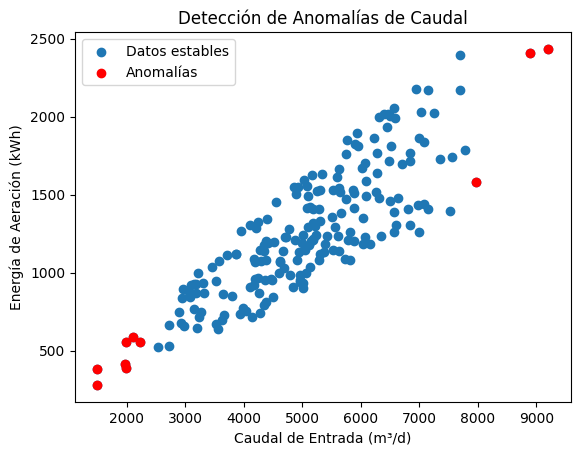

In [45]:
import matplotlib.pyplot as plt

# Graficar todos los datos
plt.scatter(data_operativa['caudal_entrada_m3_d'], data_operativa['energia_aeracion_kWh'], label='Datos estables')

# Graficar las anomalías en rojo
plt.scatter(anomalias['caudal_entrada_m3_d'], anomalias['energia_aeracion_kWh'], color='red', label='Anomalías')

plt.xlabel('Caudal de Entrada (m³/d)')
plt.ylabel('Energía de Aeración (kWh)')
plt.title('Detección de Anomalías de Caudal')
plt.legend()
plt.show()